# Project : Comorbidity Network Analysis

## 1. Dataset Description
We are using **BRFSS 2015 Diabetes & Health Indicators Dataset**.  
- Source: CDC (Center for Disease Control and Prevention)  
- Sample size: 253,680 patients  
- Columns: 22 features including diseases, lifestyle, and demographics  

**Goal:** Analyze how chronic diseases co-occur and prepare dataset for network & clustering analysis.

## 2. Dataset 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("../data/raw/diabetes_012_health_indicators_BRFSS2015.csv")

In [4]:
data.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
data.shape

(253680, 22)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [7]:
for col in data.columns:
    print(col, data[col].unique())

Diabetes_012 [0. 2. 1.]
HighBP [1. 0.]
HighChol [1. 0.]
CholCheck [1. 0.]
BMI [40. 25. 28. 27. 24. 30. 34. 26. 33. 21. 23. 22. 38. 32. 37. 31. 29. 20.
 35. 45. 39. 19. 47. 18. 36. 43. 55. 49. 42. 17. 16. 41. 44. 50. 59. 48.
 52. 46. 54. 57. 53. 14. 15. 51. 58. 63. 61. 56. 74. 62. 64. 66. 73. 85.
 60. 67. 65. 70. 82. 79. 92. 68. 72. 88. 96. 13. 81. 71. 75. 12. 77. 69.
 76. 87. 89. 84. 95. 98. 91. 86. 83. 80. 90. 78.]
Smoker [1. 0.]
Stroke [0. 1.]
HeartDiseaseorAttack [0. 1.]
PhysActivity [0. 1.]
Fruits [0. 1.]
Veggies [1. 0.]
HvyAlcoholConsump [0. 1.]
AnyHealthcare [1. 0.]
NoDocbcCost [0. 1.]
GenHlth [5. 3. 2. 4. 1.]
MentHlth [18.  0. 30.  3.  5. 15. 10.  6. 20.  2. 25.  1.  4.  7.  8. 21. 14. 26.
 29. 16. 28. 11. 12. 24. 17. 13. 27. 19. 22.  9. 23.]
PhysHlth [15.  0. 30.  2. 14. 28.  7. 20.  3. 10.  1.  5. 17.  4. 19.  6. 12. 25.
 27. 21. 22.  8. 29. 24.  9. 16. 18. 23. 13. 26. 11.]
DiffWalk [1. 0.]
Sex [0. 1.]
Age [ 9.  7. 11. 10.  8. 13.  4.  6.  2. 12.  5.  1.  3.]
Education [4. 6. 

## 3. Exploratory Data Analysis (EDA)

In [8]:
data.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [9]:
data.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

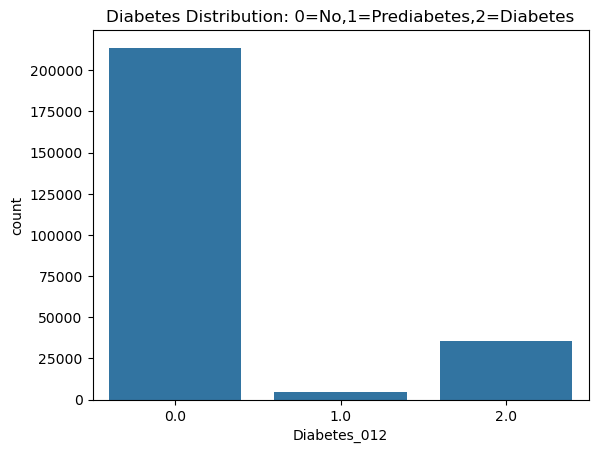

In [10]:
sns.countplot(x='Diabetes_012', data=data)
plt.title("Diabetes Distribution: 0=No,1=Prediabetes,2=Diabetes")
plt.show()

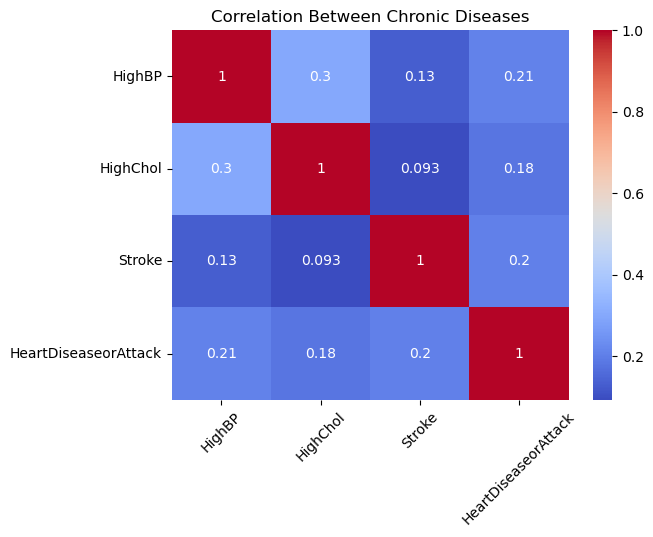

In [11]:
diseases = ['HighBP', 'HighChol', 'Stroke', 'HeartDiseaseorAttack']

sns.heatmap(data[diseases].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Chronic Diseases")
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='Diabetes_012', ylabel='BMI'>

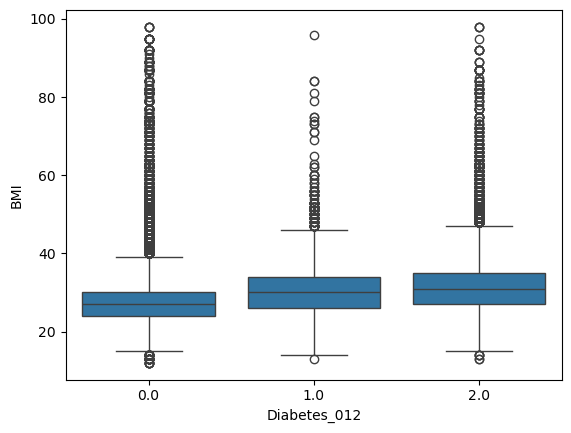

In [12]:
sns.boxplot(x='Diabetes_012', y='BMI', data=data)

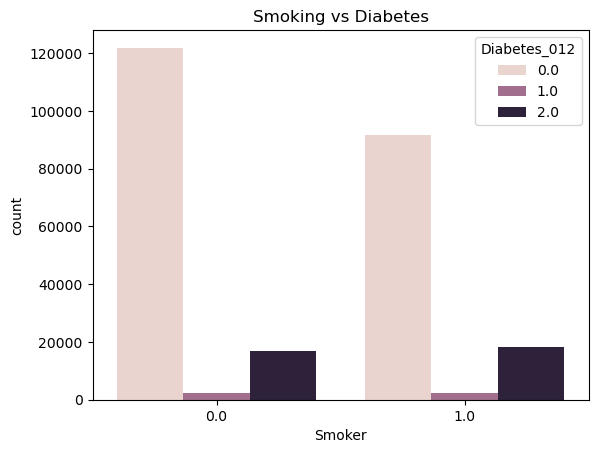

In [13]:
sns.countplot(x='Smoker', hue='Diabetes_012', data=data)
plt.title("Smoking vs Diabetes")
plt.show()

## 4. Data Preprocessing

In [14]:
data.dtypes

Diabetes_012            float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object

In [15]:
data = data.drop_duplicates()

<Axes: ylabel='BMI'>

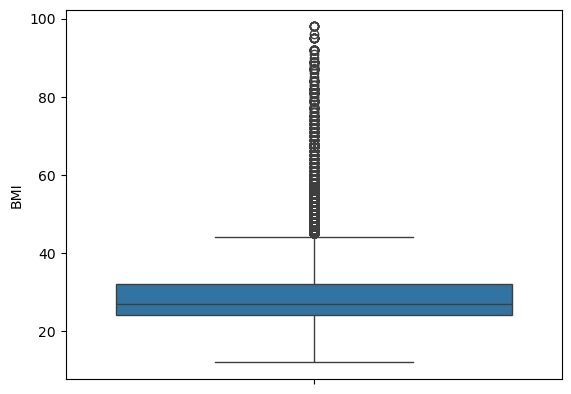

In [16]:
sns.boxplot(y=data['BMI'])

In [17]:
data = data.astype(int)
data

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0,1,1,1,45,0,0,0,0,1,...,1,0,3,0,5,0,1,5,6,7
253676,2,1,1,1,18,0,0,0,0,0,...,1,0,4,0,0,1,0,11,2,4
253677,0,0,0,1,28,0,0,0,1,1,...,1,0,1,0,0,0,0,2,5,2
253678,0,1,0,1,23,0,0,0,0,1,...,1,0,3,0,0,0,1,7,5,1


## 5. Feature Engineering

In [18]:
features = ['Age','HighBP','HighChol','Stroke','HeartDiseaseorAttack',
            'BMI','Smoker','HvyAlcoholConsump','PhysActivity',
            'Fruits','Veggies','Diabetes_012']

df_selected = data[features].copy()
df_selected.head()

,Age,HighBP,HighChol,Stroke,HeartDiseaseorAttack,BMI,Smoker,HvyAlcoholConsump,PhysActivity,Fruits,Veggies,Diabetes_012
0,9,1,1,0,0,40,1,0,0,0,1,0
1,7,0,0,0,0,25,1,0,1,0,0,0
2,9,1,1,0,0,28,0,0,0,1,0,0
3,11,1,0,0,0,27,0,0,1,1,1,0
4,11,1,1,0,0,24,0,0,1,1,1,0


In [19]:
df_selected['ComorbidityScore'] = (
    df_selected[['HighBP','HighChol','Stroke','HeartDiseaseorAttack']].sum(axis=1)
)
df_selected

,Age,HighBP,HighChol,Stroke,HeartDiseaseorAttack,BMI,Smoker,HvyAlcoholConsump,PhysActivity,Fruits,Veggies,Diabetes_012,ComorbidityScore
0,9,1,1,0,0,40,1,0,0,0,1,0,2
1,7,0,0,0,0,25,1,0,1,0,0,0,0
2,9,1,1,0,0,28,0,0,0,1,0,0,2
3,11,1,0,0,0,27,0,0,1,1,1,0,1
4,11,1,1,0,0,24,0,0,1,1,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,5,1,1,0,0,45,0,0,0,1,1,0,2
253676,11,1,1,0,0,18,0,0,0,0,0,2,2
253677,2,0,0,0,0,28,0,0,1,1,0,0,0
253678,7,1,0,0,0,23,0,0,0,1,1,0,1


In [20]:
age_mapping = {
    1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39', 5: '40-44', 6: '45-49',
    7: '50-54', 8: '55-59', 9: '60-64', 10: '65-69', 11: '70-74', 12: '75-79', 13: '80+'
}
df_selected.loc[:,'AgeGroup'] = df_selected['Age'].map(age_mapping)
df_selected.head()

,Age,HighBP,HighChol,Stroke,HeartDiseaseorAttack,BMI,Smoker,HvyAlcoholConsump,PhysActivity,Fruits,Veggies,Diabetes_012,ComorbidityScore,AgeGroup
0,9,1,1,0,0,40,1,0,0,0,1,0,2,60-64
1,7,0,0,0,0,25,1,0,1,0,0,0,0,50-54
2,9,1,1,0,0,28,0,0,0,1,0,0,2,60-64
3,11,1,0,0,0,27,0,0,1,1,1,0,1,70-74
4,11,1,1,0,0,24,0,0,1,1,1,0,2,70-74


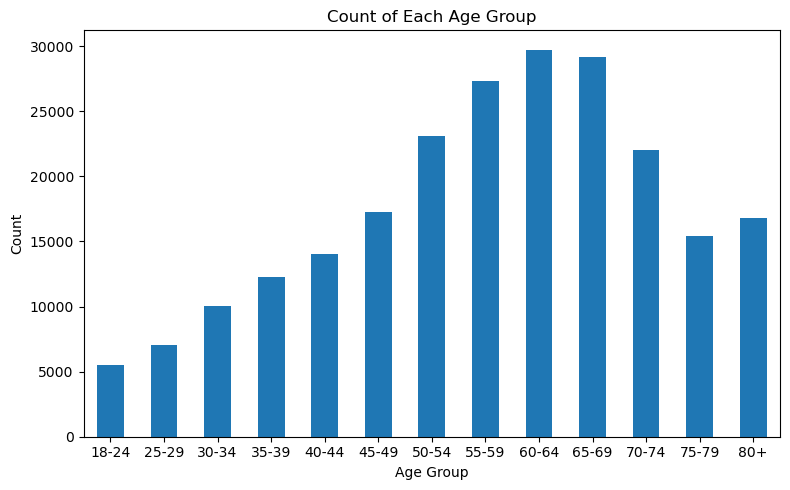

In [21]:
grouped = df_selected.groupby('AgeGroup')['Age'].count()

plt.figure(figsize=(8,5))

grouped.plot(kind='bar')
plt.title(f'Count of Each Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [22]:
df_selected['LifestyleScore'] = (
    df_selected['Smoker'] +
    df_selected['HvyAlcoholConsump'] +
    (1 - df_selected['PhysActivity']) +
    (1 - df_selected['Fruits']) +
    (1 - df_selected['Veggies'])
)
df_selected

,Age,HighBP,HighChol,Stroke,HeartDiseaseorAttack,BMI,Smoker,HvyAlcoholConsump,PhysActivity,Fruits,Veggies,Diabetes_012,ComorbidityScore,AgeGroup,LifestyleScore
0,9,1,1,0,0,40,1,0,0,0,1,0,2,60-64,3
1,7,0,0,0,0,25,1,0,1,0,0,0,0,50-54,3
2,9,1,1,0,0,28,0,0,0,1,0,0,2,60-64,2
3,11,1,0,0,0,27,0,0,1,1,1,0,1,70-74,0
4,11,1,1,0,0,24,0,0,1,1,1,0,2,70-74,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,5,1,1,0,0,45,0,0,0,1,1,0,2,40-44,1
253676,11,1,1,0,0,18,0,0,0,0,0,2,2,70-74,3
253677,2,0,0,0,0,28,0,0,1,1,0,0,0,25-29,1
253678,7,1,0,0,0,23,0,0,0,1,1,0,1,50-54,1


In [23]:
df_selected['HealthBurden'] = (
    df_selected['ComorbidityScore'] +
    df_selected['LifestyleScore'] +
    df_selected['BMI'] / 10
)
df_selected

,Age,HighBP,HighChol,Stroke,HeartDiseaseorAttack,BMI,Smoker,HvyAlcoholConsump,PhysActivity,Fruits,Veggies,Diabetes_012,ComorbidityScore,AgeGroup,LifestyleScore,HealthBurden
0,9,1,1,0,0,40,1,0,0,0,1,0,2,60-64,3,9.0
1,7,0,0,0,0,25,1,0,1,0,0,0,0,50-54,3,5.5
2,9,1,1,0,0,28,0,0,0,1,0,0,2,60-64,2,6.8
3,11,1,0,0,0,27,0,0,1,1,1,0,1,70-74,0,3.7
4,11,1,1,0,0,24,0,0,1,1,1,0,2,70-74,0,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,5,1,1,0,0,45,0,0,0,1,1,0,2,40-44,1,7.5
253676,11,1,1,0,0,18,0,0,0,0,0,2,2,70-74,3,6.8
253677,2,0,0,0,0,28,0,0,1,1,0,0,0,25-29,1,3.8
253678,7,1,0,0,0,23,0,0,0,1,1,0,1,50-54,1,4.3


In [25]:
df_selected.to_csv("../data/processed/cleaned_data.csv", index=False)